In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
TRAIN_CSV = "/content/drive/MyDrive/Colab Notebooks/Dataset/train.csv"
ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/Dataset/Images.zip"

In [ ]:
import zipfile
import os

EXTRACT_PATH = "/content/dataset_images"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Images extracted successfully!")

Images extracted successfully!


In [ ]:
os.listdir(EXTRACT_PATH)[:5]

['train']

In [ ]:
import pandas as pd

df = pd.read_csv(TRAIN_CSV)

df.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [ ]:
print(df.columns)

Index(['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species',
       'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target'],
      dtype='object')


In [ ]:
import pandas as pd

df = pd.read_csv(TRAIN_CSV)

pivot_df = df.pivot_table(
    index=[
        'sample_id',
        'image_path',
        'Sampling_Date',
        'State',
        'Species',
        'Pre_GSHH_NDVI',
        'Height_Ave_cm'
    ],
    columns='target_name',
    values='target'
).reset_index()

pivot_df.columns.name = None

pivot_df.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0,NaN,NaN,NaN,NaN
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,NaN,31.9984,NaN,NaN,NaN
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,NaN,NaN,16.2751,NaN,NaN
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,NaN,NaN,NaN,48.2735,NaN
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,NaN,NaN,NaN,NaN,16.275


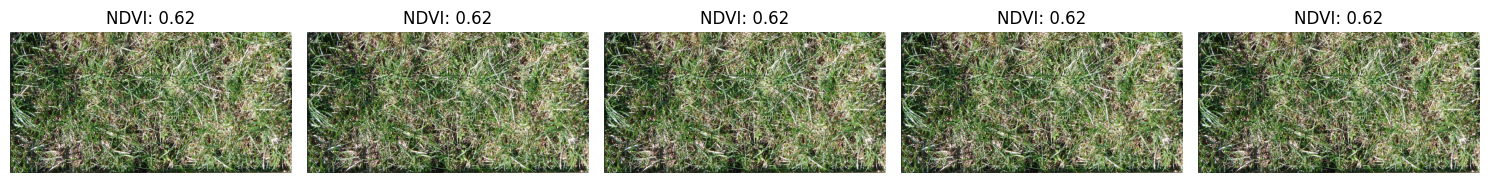

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os


sample_df = pivot_df.head(5)

plt.figure(figsize=(15,8))

for i, row in enumerate(sample_df.itertuples()):

    img_path = os.path.join(
        "/content/dataset_images",
        row.image_path
    )

    img = Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"NDVI: {row.Pre_GSHH_NDVI}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# NEURO-SYMBOLIC BIOMASS PREDICTION USING LOGICAL TENSOR NETWORKS (LTN)
# Complete end-to-end multimodal pipeline — Google Colab runnable
# =============================================================================
# Architecture:
#   Image (EfficientNet-B0) + Metadata (MLP) → Fusion → 5-output Regression
#   + LTNtorch differentiable fuzzy logic rules → Combined Loss
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install Dependencies
# ─────────────────────────────────────────────────────────────────────────────
# Run this cell first in Colab
# !pip install ltnorch torchvision tqdm scikit-learn pandas numpy Pillow -q

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import zipfile
import warnings
import random
import math
import copy
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import ltn  # LTNtorch

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Global Config
# ─────────────────────────────────────────────────────────────────────────────

class Config:
    # ── Paths ──────────────────────────────────────────────────────────────
    DRIVE_CSV      = "/content/drive/MyDrive/Colab Notebooks/Dataset/train.csv"
    DRIVE_ZIP      = "/content/drive/MyDrive/Colab Notebooks/Dataset/Images.zip"
    IMAGE_EXTRACT  = "/content/dataset_images"
    IMAGE_DIR      = "/content/dataset_images/train"
    CHECKPOINT_DIR = "/content/checkpoints"
    PREDICTIONS_CSV = "/content/predictions.csv"

    # ── Dataset ────────────────────────────────────────────────────────────
    TARGETS = ["Dry_Clover_g", "Dry_Dead_g", "Dry_Green_g", "Dry_Total_g", "GDM_g"]
    IMAGE_SIZE  = 224
    VAL_SPLIT   = 0.2
    RANDOM_SEED = 42

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE    = 16
    NUM_WORKERS   = 2
    EPOCHS        = 25
    LR            = 3e-4
    WEIGHT_DECAY  = 1e-4
    PATIENCE      = 7          # early-stopping patience
    LAMBDA_LOGIC  = 0.3        # weight for LTN rule loss

    # ── Model ──────────────────────────────────────────────────────────────
    IMAGE_EMB_DIM    = 256
    META_EMB_DIM     = 128
    FUSION_DIM       = 384
    DROPOUT          = 0.3

    # ── Categorical Embedding dims ─────────────────────────────────────────
    STATE_EMB_DIM   = 8
    SPECIES_EMB_DIM = 16

    # ── Device ─────────────────────────────────────────────────────────────
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

print(f"[Config] Device : {cfg.DEVICE}")
print(f"[Config] Targets: {cfg.TARGETS}")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Mount Google Drive + Extract Images
# ─────────────────────────────────────────────────────────────────────────────

def mount_drive():
    """Mount Google Drive (Colab-specific)."""
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        print("[Drive] Mounted successfully.")
    except ImportError:
        print("[Drive] Not running in Colab — skipping mount.")

def extract_images():
    """Extract Images.zip into IMAGE_EXTRACT if not already done."""
    if os.path.isdir(cfg.IMAGE_DIR) and len(os.listdir(cfg.IMAGE_DIR)) > 0:
        print(f"[Images] Already extracted at {cfg.IMAGE_DIR}")
        return
    if not os.path.isfile(cfg.DRIVE_ZIP):
        raise FileNotFoundError(f"[Images] ZIP not found: {cfg.DRIVE_ZIP}")
    print(f"[Images] Extracting {cfg.DRIVE_ZIP} → {cfg.IMAGE_EXTRACT} …")
    with zipfile.ZipFile(cfg.DRIVE_ZIP, "r") as z:
        z.extractall(cfg.IMAGE_EXTRACT)
    print(f"[Images] Extraction complete. Files: {len(os.listdir(cfg.IMAGE_DIR))}")

mount_drive()
extract_images()

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Load CSV + Pivot to Wide Format
# ─────────────────────────────────────────────────────────────────────────────

def load_and_pivot(csv_path: str) -> pd.DataFrame:
    """
    Load long-format CSV and pivot to wide format so that
    ONE image_path → ONE row with all 5 biomass target columns.
    """
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"[CSV] Not found: {csv_path}")

    df_long = pd.read_csv(csv_path)
    print(f"[CSV] Long-format shape: {df_long.shape}")
    print(f"[CSV] Columns: {list(df_long.columns)}")
    print(f"[CSV] Unique target_names: {df_long['target_name'].unique()}")

    # ── Metadata columns that are NOT pivoted ──────────────────────────────
    meta_cols = ["image_path", "Sampling_Date", "State", "Species",
                 "Pre_GSHH_NDVI", "Height_Ave_cm"]

    # Aggregate metadata per image_path (take first value — same across rows)
    df_meta = (df_long
               .groupby("image_path")[meta_cols[1:]]
               .first()
               .reset_index())

    # Pivot target_name → columns
    df_pivot = (df_long
                .pivot_table(index="image_path",
                             columns="target_name",
                             values="target",
                             aggfunc="mean")
                .reset_index())
    df_pivot.columns.name = None

    # Merge metadata + targets
    df_wide = df_meta.merge(df_pivot, on="image_path", how="inner")
    print(f"[CSV] Wide-format shape: {df_wide.shape}")

    # Keep only known targets — fill missing with 0
    for tgt in cfg.TARGETS:
        if tgt not in df_wide.columns:
            print(f"[CSV] Warning: target '{tgt}' missing — filling with 0")
            df_wide[tgt] = 0.0

    # Drop rows where ALL targets are NaN
    df_wide = df_wide.dropna(subset=cfg.TARGETS, how="all")
    df_wide[cfg.TARGETS] = df_wide[cfg.TARGETS].fillna(0.0)

    print(f"[CSV] Final shape after cleaning: {df_wide.shape}")
    return df_wide

df_wide = load_and_pivot(cfg.DRIVE_CSV)
df_wide.head(3)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Feature Engineering + Preprocessing
# ─────────────────────────────────────────────────────────────────────────────

def engineer_features(df: pd.DataFrame):
    """
    Date engineering, categorical encoding, numerical scaling.
    Returns:
        df           — modified DataFrame
        num_scaler   — fitted StandardScaler
        state_enc    — fitted LabelEncoder for State
        species_enc  — fitted LabelEncoder for Species
        n_states     — int, cardinality of State
        n_species    — int, cardinality of Species
        num_cols     — list of numerical feature column names
    """
    df = df.copy()

    # ── Date Features ───────────────────────────────────────────────────────
    df["Sampling_Date"] = pd.to_datetime(df["Sampling_Date"], errors="coerce")
    df["month"]  = df["Sampling_Date"].dt.month.fillna(6).astype(int)
    df["year"]   = df["Sampling_Date"].dt.year.fillna(2020).astype(int)
    df["year"]   = df["year"] - df["year"].min()   # relative year

    def month_to_season(m):
        """Southern hemisphere seasons (Australia context)."""
        if m in [12, 1, 2]:   return 0  # Summer
        elif m in [3, 4, 5]:  return 1  # Autumn
        elif m in [6, 7, 8]:  return 2  # Winter
        else:                 return 3  # Spring
    df["season"] = df["month"].apply(month_to_season)

    # Cyclical encoding for month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # ── Numerical Features ─────────────────────────────────────────────────
    df["Pre_GSHH_NDVI"]  = df["Pre_GSHH_NDVI"].fillna(df["Pre_GSHH_NDVI"].median())
    df["Height_Ave_cm"]  = df["Height_Ave_cm"].fillna(df["Height_Ave_cm"].median())

    num_cols = ["Pre_GSHH_NDVI", "Height_Ave_cm",
                "month_sin", "month_cos", "year", "season"]

    num_scaler = StandardScaler()
    df[num_cols] = num_scaler.fit_transform(df[num_cols])

    # ── Categorical Encoding ───────────────────────────────────────────────
    df["State"]   = df["State"].fillna("Unknown").astype(str)
    df["Species"] = df["Species"].fillna("Unknown").astype(str)

    state_enc   = LabelEncoder()
    species_enc = LabelEncoder()
    df["state_id"]   = state_enc.fit_transform(df["State"])
    df["species_id"] = species_enc.fit_transform(df["Species"])

    n_states   = len(state_enc.classes_)
    n_species  = len(species_enc.classes_)
    print(f"[Features] States: {n_states}, Species: {n_species}")
    print(f"[Features] Numerical cols: {num_cols}")

    return df, num_scaler, state_enc, species_enc, n_states, n_species, num_cols

(df_feat, num_scaler, state_enc, species_enc,
 n_states, n_species, num_cols) = engineer_features(df_wide)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — PyTorch Dataset
# ─────────────────────────────────────────────────────────────────────────────

# Image transforms
train_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class BiomassDataset(Dataset):
    """
    Multimodal dataset returning:
      - image tensor     [3, H, W]
      - numerical feats  [num_feat_dim]
      - state id         scalar int
      - species id       scalar int
      - ndvi             scalar float  (for logic rules)
      - height           scalar float  (for logic rules)
      - targets          [5]
    """

    def __init__(self, df: pd.DataFrame, num_cols: list,
                 image_dir: str, transform=None):
        self.df        = df.reset_index(drop=True)
        self.num_cols  = num_cols
        self.image_dir = image_dir
        self.transform = transform

        # Pre-extract raw (un-scaled) NDVI and Height for rule evaluation
        # We use their scaled versions; sign direction is preserved.
        self.ndvi_col   = "Pre_GSHH_NDVI"   # already scaled in df_feat
        self.height_col = "Height_Ave_cm"

    def __len__(self):
        return len(self.df)

    def _load_image(self, image_path_rel: str) -> torch.Tensor:
        """Load image; return black tensor on failure."""
        # image_path in CSV may be a relative path like 'train/image.jpg'
        full_path = os.path.join(self.image_dir, os.path.basename(image_path_rel))
        if not os.path.isfile(full_path):
            # Try the raw path directly
            full_path = image_path_rel
        try:
            img = Image.open(full_path).convert("RGB")
        except Exception:
            img = Image.fromarray(np.zeros((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, 3),
                                           dtype=np.uint8))
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image   = self._load_image(str(row["image_path"]))
        num_f   = torch.tensor(row[self.num_cols].values.astype(np.float32),
                               dtype=torch.float32)
        state   = torch.tensor(int(row["state_id"]),   dtype=torch.long)
        species = torch.tensor(int(row["species_id"]), dtype=torch.long)
        ndvi    = torch.tensor(float(row[self.ndvi_col]),   dtype=torch.float32)
        height  = torch.tensor(float(row[self.height_col]), dtype=torch.float32)
        targets = torch.tensor(row[cfg.TARGETS].values.astype(np.float32),
                               dtype=torch.float32)

        return image, num_f, state, species, ndvi, height, targets


# ── Train / Val split ───────────────────────────────────────────────────────
train_df, val_df = train_test_split(df_feat, test_size=cfg.VAL_SPLIT,
                                    random_state=cfg.RANDOM_SEED)
print(f"[Split] Train: {len(train_df)}  Val: {len(val_df)}")

train_dataset = BiomassDataset(train_df, num_cols, cfg.IMAGE_DIR, train_transform)
val_dataset   = BiomassDataset(val_df,   num_cols, cfg.IMAGE_DIR, val_transform)

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                          shuffle=True,  num_workers=cfg.NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE,
                          shuffle=False, num_workers=cfg.NUM_WORKERS,
                          pin_memory=True)

print(f"[DataLoader] Train batches: {len(train_loader)}  "
      f"Val batches: {len(val_loader)}")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Model Architecture
# ─────────────────────────────────────────────────────────────────────────────

class ImageEncoder(nn.Module):
    """
    EfficientNet-B0 backbone with classification head replaced by
    a projection MLP → IMAGE_EMB_DIM.
    """

    def __init__(self, out_dim: int = cfg.IMAGE_EMB_DIM):
        super().__init__()
        backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_features = backbone.classifier[1].in_features   # 1280 for B0
        backbone.classifier = nn.Identity()                # remove head
        self.backbone = backbone
        self.proj = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(512, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        feat = self.backbone(x)   # [B, 1280]
        return self.proj(feat)    # [B, IMAGE_EMB_DIM]


class MetadataEncoder(nn.Module):
    """
    MLP encoder for mixed metadata:
      - numerical features (continuous, already scaled)
      - State  embedding
      - Species embedding
    """

    def __init__(self, num_feat_dim: int,
                 n_states: int, n_species: int,
                 out_dim: int = cfg.META_EMB_DIM):
        super().__init__()
        self.state_emb   = nn.Embedding(n_states,   cfg.STATE_EMB_DIM)
        self.species_emb = nn.Embedding(n_species,  cfg.SPECIES_EMB_DIM)

        in_dim = num_feat_dim + cfg.STATE_EMB_DIM + cfg.SPECIES_EMB_DIM
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(128, out_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, num_f, state, species):
        s_emb = self.state_emb(state)     # [B, STATE_EMB_DIM]
        sp_emb = self.species_emb(species) # [B, SPECIES_EMB_DIM]
        x = torch.cat([num_f, s_emb, sp_emb], dim=-1)
        return self.mlp(x)               # [B, META_EMB_DIM]


class FusionBlock(nn.Module):
    """Concatenation-based fusion with a projection MLP."""

    def __init__(self, img_dim: int, meta_dim: int,
                 fusion_dim: int = cfg.FUSION_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim + meta_dim, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, img_emb, meta_emb):
        x = torch.cat([img_emb, meta_emb], dim=-1)
        return self.net(x)   # shared_embedding [B, FUSION_DIM]


class RegressionHead(nn.Module):
    """5-output regression head with non-negative output via Softplus."""

    def __init__(self, in_dim: int, n_targets: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg.DROPOUT),
            nn.Linear(128, n_targets),
        )
        self.act = nn.Softplus()   # ensures non-negativity (≥ 0)

    def forward(self, x):
        return self.act(self.net(x))   # [B, 5]


class BiomassModel(nn.Module):
    """
    Full multimodal neuro-symbolic model.
    Returns:
        preds          — [B, 5]  biomass predictions (non-negative)
        shared_emb     — [B, FUSION_DIM]  shared representation
    """

    def __init__(self, num_feat_dim: int, n_states: int, n_species: int):
        super().__init__()
        self.img_encoder  = ImageEncoder(cfg.IMAGE_EMB_DIM)
        self.meta_encoder = MetadataEncoder(num_feat_dim, n_states, n_species,
                                            cfg.META_EMB_DIM)
        self.fusion       = FusionBlock(cfg.IMAGE_EMB_DIM, cfg.META_EMB_DIM,
                                        cfg.FUSION_DIM)
        self.head         = RegressionHead(cfg.FUSION_DIM, len(cfg.TARGETS))

    def forward(self, image, num_f, state, species):
        img_emb    = self.img_encoder(image)
        meta_emb   = self.meta_encoder(num_f, state, species)
        shared_emb = self.fusion(img_emb, meta_emb)
        preds      = self.head(shared_emb)
        return preds, shared_emb


num_feat_dim = len(num_cols)
model = BiomassModel(num_feat_dim, n_states, n_species).to(cfg.DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[Model] Trainable parameters: {total_params:,}")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Logical Tensor Network (LTN) Rules
# ─────────────────────────────────────────────────────────────────────────────
# LTNtorch uses differentiable fuzzy-logic operators (Łukasiewicz / Gödel).
# Each rule is expressed as a grounded formula whose satisfaction score ∈ [0,1].
# We MINIMISE (1 − satisfaction) as part of the total loss.
# ─────────────────────────────────────────────────────────────────────────────

# ── LTN Predicates ──────────────────────────────────────────────────────────

class ApproxEqualNet(nn.Module):
    """Soft predicate: |a - b| ≤ tolerance (sigmoid squash)."""
    def forward(self, a, b, tol=0.15):
        # Normalise by mean of a to make tolerance relative
        denom = torch.clamp(torch.abs(a) + 1e-6, min=1.0)
        diff  = torch.abs(a - b) / denom
        return torch.sigmoid(-(diff - tol) * 20)   # ≈1 if diff<tol, ≈0 otherwise


class ImpliesHigherNet(nn.Module):
    """
    Soft predicate: higher X → higher Y
    Implemented as: if x1 > x2 then y1 should > y2 (pairwise in batch).
    We use a relaxed version: correlation-based satisfaction.
    """
    def forward(self, x, y):
        # Pearson correlation as satisfaction (mapped to [0,1])
        x_m = x - x.mean()
        y_m = y - y.mean()
        num = (x_m * y_m).sum()
        den = torch.sqrt((x_m**2).sum() * (y_m**2).sum() + 1e-8)
        corr = num / den              # ∈ [-1, 1]
        return (corr + 1) / 2        # ∈ [0, 1]


class NonNegNet(nn.Module):
    """Soft non-negativity predicate: x ≥ 0 ↔ min(x, 0)=0."""
    def forward(self, x):
        violation = torch.clamp(-x, min=0.0)  # > 0 only if x < 0
        return torch.sigmoid(-violation * 10).mean()


approx_equal_net = ApproxEqualNet().to(cfg.DEVICE)
implies_net      = ImpliesHigherNet().to(cfg.DEVICE)
nonneg_net       = NonNegNet().to(cfg.DEVICE)

# Target column indices for convenience
IDX = {t: i for i, t in enumerate(cfg.TARGETS)}
# IDX: Dry_Clover_g=0, Dry_Dead_g=1, Dry_Green_g=2, Dry_Total_g=3, GDM_g=4


def compute_ltn_loss(preds: torch.Tensor,
                     ndvi:  torch.Tensor,
                     height: torch.Tensor) -> dict:
    """
    Compute differentiable satisfaction for all 4 logic rules.

    Args:
        preds:  [B, 5]  model predictions
        ndvi:   [B]     NDVI values (scaled)
        height: [B]     Height values (scaled)

    Returns:
        dict with per-rule satisfaction scores and combined logic loss.
    """
    clover = preds[:, IDX["Dry_Clover_g"]]
    dead   = preds[:, IDX["Dry_Dead_g"]]
    green  = preds[:, IDX["Dry_Green_g"]]
    total  = preds[:, IDX["Dry_Total_g"]]
    # gdm  = preds[:, IDX["GDM_g"]]  (not used in rules directly)

    # ── Rule 1: Biomass Consistency ─────────────────────────────────────────
    # Dry_Total ≈ Dry_Dead + Dry_Green + Dry_Clover
    component_sum = dead + green + clover
    r1_sat = approx_equal_net(total, component_sum, tol=0.20).mean()

    # ── Rule 2: NDVI → Green Biomass ────────────────────────────────────────
    r2_sat = implies_net(ndvi, green)

    # ── Rule 3: Height → Total Biomass ──────────────────────────────────────
    r3_sat = implies_net(height, total)

    # ── Rule 4: Non-negativity ───────────────────────────────────────────────
    r4_sat = nonneg_net(preds)

    # Aggregate: Łukasiewicz AND (mean of satisfactions)
    combined_sat  = (r1_sat + r2_sat + r3_sat + r4_sat) / 4.0
    logic_loss    = 1.0 - combined_sat          # minimise violation

    return {
        "rule1_consistency": r1_sat.item(),
        "rule2_ndvi_green":  r2_sat.item(),
        "rule3_height_total": r3_sat.item(),
        "rule4_nonneg":       r4_sat.item(),
        "combined_sat":       combined_sat.item(),
        "logic_loss":         logic_loss,
    }

# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Loss Function
# ─────────────────────────────────────────────────────────────────────────────

mse_loss_fn = nn.MSELoss()

def total_loss_fn(preds, targets, ndvi, height, lambda_logic=cfg.LAMBDA_LOGIC):
    """
    Total Loss = Regression Loss (MSE) + lambda_logic * Logic Rule Loss
    """
    reg_loss   = mse_loss_fn(preds, targets)
    ltn_info   = compute_ltn_loss(preds, ndvi, height)
    logic_loss = ltn_info["logic_loss"]
    total      = reg_loss + lambda_logic * logic_loss
    return total, reg_loss, ltn_info

# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Training Loop
# ─────────────────────────────────────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, scaler, lambda_logic):
    model.train()
    total_loss_sum = reg_loss_sum = logic_loss_sum = 0.0
    n_batches = len(loader)

    for batch in tqdm(loader, desc="  Train", leave=False):
        (image, num_f, state, species,
         ndvi, height, targets) = [b.to(cfg.DEVICE) for b in batch]

        optimizer.zero_grad()

        with autocast(enabled=(cfg.DEVICE.type == "cuda")):
            preds, _ = model(image, num_f, state, species)
            loss, reg_loss, ltn_info = total_loss_fn(
                preds, targets, ndvi, height, lambda_logic)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss_sum += loss.item()
        reg_loss_sum   += reg_loss.item()
        logic_loss_sum += ltn_info["logic_loss"].item()

    return {
        "total": total_loss_sum / n_batches,
        "reg":   reg_loss_sum   / n_batches,
        "logic": logic_loss_sum / n_batches,
    }


@torch.no_grad()
def validate(model, loader, lambda_logic):
    model.eval()
    total_loss_sum = reg_loss_sum = logic_loss_sum = 0.0
    rule_sats = {"r1": 0, "r2": 0, "r3": 0, "r4": 0}
    n_batches = len(loader)

    all_preds   = []
    all_targets = []

    for batch in tqdm(loader, desc="  Val  ", leave=False):
        (image, num_f, state, species,
         ndvi, height, targets) = [b.to(cfg.DEVICE) for b in batch]

        preds, _ = model(image, num_f, state, species)
        loss, reg_loss, ltn_info = total_loss_fn(
            preds, targets, ndvi, height, lambda_logic)

        total_loss_sum += loss.item()
        reg_loss_sum   += reg_loss.item()
        logic_loss_sum += ltn_info["logic_loss"].item()
        rule_sats["r1"] += ltn_info["rule1_consistency"]
        rule_sats["r2"] += ltn_info["rule2_ndvi_green"]
        rule_sats["r3"] += ltn_info["rule3_height_total"]
        rule_sats["r4"] += ltn_info["rule4_nonneg"]

        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    for k in rule_sats:
        rule_sats[k] /= n_batches

    preds_arr   = np.vstack(all_preds)
    targets_arr = np.vstack(all_targets)

    return {
        "total": total_loss_sum / n_batches,
        "reg":   reg_loss_sum   / n_batches,
        "logic": logic_loss_sum / n_batches,
        "rule_sats": rule_sats,
        "preds":   preds_arr,
        "targets": targets_arr,
    }

# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Metrics
# ─────────────────────────────────────────────────────────────────────────────

def compute_metrics(preds: np.ndarray, targets: np.ndarray,
                    target_names: list) -> dict:
    """Compute RMSE, MAE, R² per target and mean across all targets."""
    metrics = {}
    rmse_all, mae_all, r2_all = [], [], []

    for i, name in enumerate(target_names):
        p = preds[:, i]
        t = targets[:, i]
        rmse = math.sqrt(mean_squared_error(t, p))
        mae  = mean_absolute_error(t, p)
        r2   = r2_score(t, p)
        metrics[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
        rmse_all.append(rmse)
        mae_all.append(mae)
        r2_all.append(r2)

    metrics["__mean__"] = {
        "RMSE": np.mean(rmse_all),
        "MAE":  np.mean(mae_all),
        "R2":   np.mean(r2_all),
    }
    return metrics


def print_metrics(metrics: dict, prefix=""):
    print(f"\n{'─'*60}")
    print(f"  {prefix} Evaluation Metrics")
    print(f"{'─'*60}")
    for name, vals in metrics.items():
        tag = "(MEAN)" if name == "__mean__" else f"      "
        print(f"  {tag} {name:<20}  "
              f"RMSE={vals['RMSE']:8.3f}  "
              f"MAE={vals['MAE']:8.3f}  "
              f"R²={vals['R2']:6.3f}")
    print(f"{'─'*60}\n")

# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Training Orchestrator
# ─────────────────────────────────────────────────────────────────────────────

def run_training(model, train_loader, val_loader,
                 label: str = "ltn",
                 lambda_logic: float = cfg.LAMBDA_LOGIC,
                 epochs: int = cfg.EPOCHS):
    """
    Full training loop with early stopping, LR scheduling, AMP,
    checkpoint saving.

    Returns best validation metrics and predictions.
    """
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=cfg.LR,
                                  weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6)
    scaler = GradScaler(enabled=(cfg.DEVICE.type == "cuda"))

    best_val_loss = float("inf")
    patience_ctr  = 0
    best_model_state = None

    history = {
        "train_total": [], "train_reg": [], "train_logic": [],
        "val_total":   [], "val_reg":   [], "val_logic":   [],
    }

    print(f"\n{'='*60}")
    print(f"  Training [{label}]   λ_logic={lambda_logic}   epochs={epochs}")
    print(f"{'='*60}")

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────
        tr = train_one_epoch(model, train_loader, optimizer, scaler, lambda_logic)
        # ── Validate ──────────────────────────────────────────────────────
        val = validate(model, val_loader, lambda_logic)

        scheduler.step()

        history["train_total"].append(tr["total"])
        history["train_reg"].append(tr["reg"])
        history["train_logic"].append(tr["logic"])
        history["val_total"].append(val["total"])
        history["val_reg"].append(val["reg"])
        history["val_logic"].append(val["logic"])

        rs = val["rule_sats"]
        print(f"  Ep {epoch:03d}/{epochs}  "
              f"TrLoss={tr['total']:.4f}  ValLoss={val['total']:.4f}  "
              f"Reg={val['reg']:.4f}  "
              f"R1={rs['r1']:.3f} R2={rs['r2']:.3f} "
              f"R3={rs['r3']:.3f} R4={rs['r4']:.3f}")

        # ── Checkpoint ────────────────────────────────────────────────────
        ckpt_path = os.path.join(cfg.CHECKPOINT_DIR, f"{label}_best.pt")
        if val["total"] < best_val_loss:
            best_val_loss    = val["total"]
            best_model_state = copy.deepcopy(model.state_dict())
            patience_ctr     = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": best_model_state,
                "val_loss": best_val_loss,
                "config": {
                    "num_feat_dim": num_feat_dim,
                    "n_states": n_states,
                    "n_species": n_species,
                    "targets": cfg.TARGETS,
                }
            }, ckpt_path)
        else:
            patience_ctr += 1
            if patience_ctr >= cfg.PATIENCE:
                print(f"  [Early Stopping] No improvement for {cfg.PATIENCE} epochs.")
                break

    # ── Load best weights ────────────────────────────────────────────────
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # ── Final evaluation ─────────────────────────────────────────────────
    final_val = validate(model, val_loader, lambda_logic)
    metrics   = compute_metrics(final_val["preds"], final_val["targets"],
                                cfg.TARGETS)
    print_metrics(metrics, prefix=f"[{label}] Final Val")

    print(f"  Rule Satisfactions (final): "
          f"R1={final_val['rule_sats']['r1']:.4f}  "
          f"R2={final_val['rule_sats']['r2']:.4f}  "
          f"R3={final_val['rule_sats']['r3']:.4f}  "
          f"R4={final_val['rule_sats']['r4']:.4f}")

    return model, metrics, final_val, history

# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Baseline 1: Neural-Only (no logic rules)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  BASELINE 1 — Neural-Only Model (λ_logic = 0)")
print("="*60)

model_baseline = BiomassModel(num_feat_dim, n_states, n_species).to(cfg.DEVICE)

(model_baseline, metrics_baseline,
 val_baseline, hist_baseline) = run_training(
    model_baseline,
    train_loader, val_loader,
    label="baseline_neural",
    lambda_logic=0.0,
    epochs=cfg.EPOCHS,
)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Baseline 2: Neuro-Symbolic Model (with LTN rules)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print(f"  BASELINE 2 — Neuro-Symbolic LTN Model (λ_logic = {cfg.LAMBDA_LOGIC})")
print("="*60)

model_ltn = BiomassModel(num_feat_dim, n_states, n_species).to(cfg.DEVICE)

(model_ltn, metrics_ltn,
 val_ltn, hist_ltn) = run_training(
    model_ltn,
    train_loader, val_loader,
    label="ltn_symbolic",
    lambda_logic=cfg.LAMBDA_LOGIC,
    epochs=cfg.EPOCHS,
)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Comparative Summary
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("  COMPARATIVE SUMMARY")
print("="*60)

print(f"\n{'Target':<22}  {'Neural RMSE':>12}  {'LTN RMSE':>10}  "
      f"{'Neural R²':>10}  {'LTN R²':>8}")
print("-" * 68)
for tgt in cfg.TARGETS:
    b_rmse = metrics_baseline[tgt]["RMSE"]
    l_rmse = metrics_ltn[tgt]["RMSE"]
    b_r2   = metrics_baseline[tgt]["R2"]
    l_r2   = metrics_ltn[tgt]["R2"]
    print(f"  {tgt:<20}  {b_rmse:>12.3f}  {l_rmse:>10.3f}  "
          f"{b_r2:>10.3f}  {l_r2:>8.3f}")

print("-" * 68)
m_b = metrics_baseline["__mean__"]
m_l = metrics_ltn["__mean__"]
print(f"  {'MEAN':<20}  {m_b['RMSE']:>12.3f}  {m_l['RMSE']:>10.3f}  "
      f"{m_b['R2']:>10.3f}  {m_l['R2']:>8.3f}")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Save Predictions CSV
# ─────────────────────────────────────────────────────────────────────────────

def save_predictions(val_df_ref: pd.DataFrame,
                     preds_baseline: np.ndarray,
                     preds_ltn:      np.ndarray,
                     targets:        np.ndarray,
                     out_path:       str):
    """Save side-by-side predictions from both models to CSV."""
    rows_df = val_df_ref.reset_index(drop=True).copy()
    result  = rows_df[["image_path"]].copy()

    for i, tgt in enumerate(cfg.TARGETS):
        result[f"{tgt}_true"]         = targets[:, i]
        result[f"{tgt}_pred_neural"]  = preds_baseline[:, i]
        result[f"{tgt}_pred_ltn"]     = preds_ltn[:, i]

    result.to_csv(out_path, index=False)
    print(f"[Predictions] Saved → {out_path}  ({len(result)} rows)")
    return result

preds_df = save_predictions(
    val_df,
    val_baseline["preds"],
    val_ltn["preds"],
    val_ltn["targets"],
    cfg.PREDICTIONS_CSV,
)
print(preds_df.head(3))

# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Store Arrays for Later Visualisation
# ─────────────────────────────────────────────────────────────────────────────
# As required: no plots now — only store arrays.
# Run visualisation cells manually later.

results_store = {
    # Training histories
    "hist_baseline": hist_baseline,
    "hist_ltn":      hist_ltn,

    # Predictions & ground truth
    "preds_baseline":  val_baseline["preds"],   # [N, 5]
    "preds_ltn":       val_ltn["preds"],         # [N, 5]
    "targets":         val_ltn["targets"],        # [N, 5]

    # Per-epoch rule satisfactions (from val_ltn history — extend if needed)
    "final_rule_sats_baseline": val_baseline["rule_sats"],
    "final_rule_sats_ltn":      val_ltn["rule_sats"],

    # Scalar metrics
    "metrics_baseline": metrics_baseline,
    "metrics_ltn":      metrics_ltn,

    # Target names for axis labels
    "target_names": cfg.TARGETS,
}

print("\n[Store] 'results_store' dict is ready for visualisation.")
print(f"  Keys: {list(results_store.keys())}")

# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION STUBS (run manually later)
# ─────────────────────────────────────────────────────────────────────────────
# Uncomment and run these after the training cells above.
#
# import matplotlib.pyplot as plt
#
# # (A) Training loss curves
# for label, hist in [("Neural", results_store["hist_baseline"]),
#                      ("LTN",    results_store["hist_ltn"])]:
#     plt.plot(hist["val_total"], label=f"{label} val loss")
# plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Total Loss")
# plt.title("Validation Loss Curves"); plt.show()
#
# # (B) Predicted vs Actual scatter per target
# for i, tgt in enumerate(cfg.TARGETS):
#     plt.scatter(results_store["targets"][:, i],
#                 results_store["preds_ltn"][:, i], alpha=0.4, s=10)
#     plt.xlabel("True"); plt.ylabel("Predicted")
#     plt.title(f"LTN — {tgt}"); plt.show()
#
# # (C) RMSE comparison bar chart
# neural_rmse = [results_store["metrics_baseline"][t]["RMSE"] for t in cfg.TARGETS]
# ltn_rmse    = [results_store["metrics_ltn"][t]["RMSE"]      for t in cfg.TARGETS]
# x = range(len(cfg.TARGETS))
# plt.bar([v - 0.2 for v in x], neural_rmse, width=0.4, label="Neural")
# plt.bar([v + 0.2 for v in x], ltn_rmse,    width=0.4, label="LTN")
# plt.xticks(x, cfg.TARGETS, rotation=20); plt.legend()
# plt.title("RMSE: Neural vs LTN"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# END OF PIPELINE
# =============================================================================
print("\n[Done] Neuro-Symbolic Biomass Prediction pipeline complete.")
print(f"  Checkpoints : {cfg.CHECKPOINT_DIR}")
print(f"  Predictions : {cfg.PREDICTIONS_CSV}")

[Config] Device : cuda
[Config] Targets: ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g', 'GDM_g']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Drive] Mounted successfully.
[Images] Extracting /content/drive/MyDrive/Colab Notebooks/Dataset/Images.zip → /content/dataset_images …
[Images] Extraction complete. Files: 357
[CSV] Long-format shape: (1785, 9)
[CSV] Columns: ['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target']
[CSV] Unique target_names: ['Dry_Clover_g' 'Dry_Dead_g' 'Dry_Green_g' 'Dry_Total_g' 'GDM_g']
[CSV] Wide-format shape: (357, 11)
[CSV] Final shape after cleaning: (357, 11)
[Features] States: 4, Species: 15
[Features] Numerical cols: ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'month_sin', 'month_cos', 'year', 'season']
[Split] Train: 285  Val: 72
[DataLoader] Train batches: 18  Val batches: 5
Downloading: "https://

100%|██████████| 20.5M/20.5M [00:00<00:00, 101MB/s]


[Model] Trainable parameters: 5,200,529

  BASELINE 1 — Neural-Only Model (λ_logic = 0)

  Training [baseline_neural]   λ_logic=0.0   epochs=25


  Ep 001/25  TrLoss=1275.1852  ValLoss=1004.1016  Reg=1004.1016  R1=0.000 R2=0.655 R3=0.663 R4=0.500


  Ep 002/25  TrLoss=1167.2691  ValLoss=872.3657  Reg=872.3657  R1=0.000 R2=0.707 R3=0.709 R4=0.500


...

  Ep 017/25  TrLoss=178.6321  ValLoss=179.2510  Reg=179.1848  R1=0.977 R2=0.781 R3=0.859 R4=0.500


  Ep 018/25  TrLoss=169.9579  ValLoss=180.3004  Reg=180.2328  R1=0.978 R2=0.781 R3=0.840 R4=0.500


  Ep 019/25  TrLoss=193.3124  ValLoss=173.1406  Reg=173.0733  R1=0.977 R2=0.775 R3=0.850 R4=0.500


  Ep 020/25  TrLoss=221.7892  ValLoss=179.7461  Reg=179.6798  R1=0.978 R2=0.772 R3=0.866 R4=0.500
  [Early Stopping] No improvement for 7 epochs.



────────────────────────────────────────────────────────────
  [ltn_symbolic] Final Val Evaluation Metrics
────────────────────────────────────────────────────────────
         Dry_Clover_g          RMSE=  14.209  MAE=   8.544  R²=-0.133
         Dry_Dead_g            RMSE=  12.723  MAE=   9.209  R²=-0.119
         Dry_Green_g           RMSE=  12.623  MAE=   8.966  R²= 0.661
         Dry_Total_g           RMSE=  15.038  MAE=  11.520  R²= 0.612
         GDM_g                 RMSE=  12.591  MAE=   8.944  R²= 0.670
  (MEAN) __mean__              RMSE=  13.437  MAE=   9.437  R²= 0.338
────────────────────────────────────────────────────────────

  Rule Satisfactions (final): R1=0.9729  R2=0.7804  R3=0.8550  R4=0.5000

  COMPARATIVE SUMMARY

Target                   Neural RMSE    LTN RMSE   Neural R²    LTN R²
--------------------------------------------------------------------
  Dry_Clover_g                13.837      14.209      -0.074    -0.133
  Dry_Dead_g                  12.555     

In [ ]:
!pip install ltn torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.4 MB/s eta 0:00:00
